In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import (
    FIGURES_PATH,
    NUM_PRODUCTS,
    NUM_TIMESTEPS,
    P_DIFF,
    P_MAX,
    P_MIN,
    RANDOM_SENS_PROBS_LIST,
    SEED_LIST,
    K,
)
from fair_dynamic_pricing_with_rl.utils.experiment_utils import argmedian
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index
from fair_dynamic_pricing_with_rl.utils.config import PRODUCT_LIST

In [2]:
PARAMETER_NAME_DICT = {
    "experiment_1": "random_action_prob",
    "experiment_2": "fairness_weight",
    "experiment_3": "random_sens_prob"
}

In [3]:
def calculate_final_results_table(experiment_name: str,
                                  experiment_parameter_mapping:dict = PARAMETER_NAME_DICT):
    """Reads and amends results table with additional metrics on fairness.
    """
    results = pd.read_csv(f"../output/{experiment_name}/results.csv")

    # query main parameter name from mapping
    parameter_name = experiment_parameter_mapping[experiment_name]

    # calculate absolute difference and this relative to pure PPO
    results["abs_diff (USD)"] = np.abs(results["nonsnap_price"] - results["snap_price"])
    ppo_abs_diff = results.loc[results[parameter_name]==0.0,"abs_diff (USD)"].to_numpy()
    results["abs_diff (% of vanilla-PPO)"] = (results["abs_diff (USD)"] / ppo_abs_diff)*100

    # return result table
    return results

# Experiment 1

In [4]:
calculate_final_results_table("experiment_1")

,mean_episode_revenue,jains_index,random_action_prob,nonsnap_price,snap_price,abs_diff (USD),abs_diff (% of vanilla-PPO)
0,9883.362869,1.000000,0.000000,16.486475,16.467960,0.018515,100.000000
1,8165.937283,1.000000,0.111111,16.232375,16.216960,0.015415,83.256819
2,6797.985967,0.999999,0.222222,15.968060,15.941615,0.026445,142.830138
3,5634.660152,0.999999,0.333333,15.650278,15.623750,0.026527,143.275722
4,4822.652549,1.000000,0.444444,15.471727,15.457720,0.014007,75.654874
5,3458.509325,0.999999,0.555556,15.104100,15.078690,0.025410,137.240076
6,2712.140846,1.000000,0.666667,14.842290,14.830320,0.011970,64.650284
7,2066.258489,1.000000,0.777778,14.549559,14.560280,0.010721,57.905752
8,1425.207691,0.999997,0.888889,14.302687,14.252987,0.049700,268.431002
9,795.715151,1.000000,1.000000,13.996894,14.016380,0.019486,105.245747


# Experiment 2

In [5]:
calculate_final_results_table("experiment_2")

,mean_episode_revenue,jains_index,fairness_weight,nonsnap_price,snap_price,abs_diff (USD),abs_diff (% of vanilla-PPO)
0,6827.956917,0.999946,0.000000,16.749350,16.504105,0.245245,100.000000
1,6709.546837,1.000000,0.111111,16.690110,16.691567,0.001457,0.594304
2,6749.764118,1.000000,0.222222,16.710048,16.705468,0.004580,1.867520
3,6752.074180,1.000000,0.333333,16.721602,16.715130,0.006472,2.639198
4,6251.358512,1.000000,0.444444,16.454600,16.455122,0.000522,0.213052
5,4663.040929,0.999992,0.555556,15.710344,15.621950,0.088394,36.043039
6,4437.941348,1.000000,0.666667,15.569405,15.552942,0.016463,6.712675
7,3425.028308,1.000000,0.777778,14.939516,14.920642,0.018874,7.695876
8,2363.365764,1.000000,0.888889,14.918924,14.907262,0.011661,4.754939
9,315.336115,1.000000,1.000000,14.323369,14.315780,0.007589,3.094355


# Experiment 3

In [6]:
experiment3_results = calculate_final_results_table("experiment_3")
experiment3_results

,mean_episode_revenue,jains_index,nonsnap_price,snap_price,random_sens_prob,abs_diff (USD),abs_diff (% of vanilla-PPO)
0,9883.362869,1.0,16.486475,16.467960,0.000000,0.018515,100.000000
1,8887.323744,1.0,16.325956,16.319205,0.111111,0.006751,36.463678
2,9660.560201,1.0,16.460703,16.459592,0.222222,0.001110,5.995139
3,9004.465841,1.0,16.402855,16.404275,0.333333,0.001420,7.669457
4,8760.404420,1.0,16.360042,16.358900,0.444444,0.001143,6.170672
5,7999.545048,1.0,16.265490,16.261170,0.555556,0.004320,23.332433
6,8998.872596,1.0,16.402752,16.402637,0.666667,0.000115,0.621118
7,9006.587612,1.0,16.403472,16.400740,0.777778,0.002733,14.758304
8,10524.553606,1.0,16.664234,16.650703,0.888889,0.013531,73.082636
9,9881.032466,1.0,16.486718,16.468808,1.000000,0.017910,96.732379


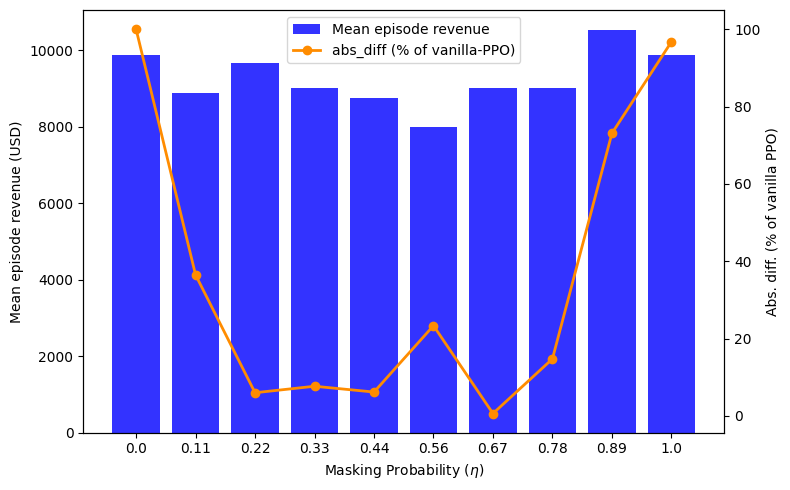

In [7]:
x = np.arange(len(experiment3_results))

fig, ax1 = plt.subplots(figsize=(8, 5))

# create barplot of mean episodic revenue
ax1.bar(x, experiment3_results["mean_episode_revenue"], color="blue", alpha=0.8, label="Mean episode revenue")

# note: x axis labels are plotted as discrete
ax1.set_xticks(x)
ax1.set_xticklabels(np.round(experiment3_results["random_sens_prob"],2))

# create dual y-axis then plot abs. diff. (as % of pure PPO)
ax2 = ax1.twinx()
ax2.plot(x,
         experiment3_results["abs_diff (% of vanilla-PPO)"],
         color="darkorange",
         marker="o",
         linewidth=2,
         label="abs_diff (% of vanilla-PPO)")

# add axis labels
ax1.set_xlabel(r"Masking Probability ($\eta$)")
ax1.set_ylabel("Mean episode revenue (USD)")
ax2.set_ylabel("Abs. diff. (% of vanilla PPO)")

# single combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper center")

plt.tight_layout()
plt.savefig(FIGURES_PATH + "experiment_3_revenue_vs_absdiff.pdf", format="pdf", bbox_inches="tight")